# Constrained sampling on the ball: $J=0$ against the admissible skew $J_s$

Target restricted to the Euclidean ball

$$K=\{x\in\mathbb R^3:\ \lVert x\rVert_2\le R\},\qquad
\pi(x)\;\propto\;e^{-U(x)}\,\mathbf 1_K(x),$$

on two targets, comparing $J=0$ against the state-dependent skew $J_s$ at $s=4,8,16$.

## Only admissible fields appear here

This is a constrained problem, so the constant skew $J_a$ is simply not a candidate and has been dropped.
Sampling on $K$ by projection requires the skew drift to be **tangential at the wall**,

$$J(x)\,\nu(x)=0\quad\text{for }x\in\partial K,\qquad \nu(x)=x/\lVert x\rVert,$$

and a constant $J_a$ fails that by construction — it drives $O(s)$ flux straight into the boundary, the
projection absorbs it, and the stationary law is wrong by an amount no stepsize refinement removes. There
is nothing to learn from racing against it on a constrained problem.

## The field

For a constant antisymmetric $A$,

$$\boxed{\;J_s(x)\;=\;\frac{s}{R^2}\Bigl[\lVert x\rVert^2A+x\,(Ax)^{\!\top}-(Ax)\,x^{\!\top}\Bigr]\;}$$

It is antisymmetric for every $x$, and it annihilates $x$ **identically**:
$J_s(x)x=\tfrac{s}{R^2}[r^2Ax+x\,(Ax)^{\!\top}x-(Ax)r^2]=0$ since $(Ax)^{\!\top}x=0$. So $J_s\nu=0$ on
$\partial K$ by construction, not by tuning.

$A$ is free, which is the point: the rotation is put in the plane of the two largest-variance eigenvectors
of $\Sigma$ — the directions the sampler crawls along. (The cross-product field $s\,(x\times w)$ of the
earlier notebooks is also admissible, but it rotates about $x$, so its plane is dictated by position and
cannot be aimed. Experiment 1 shows what aiming is worth.)

The price of that freedom is that $J_s$ is **not** divergence-free,

$$(\nabla\!\cdot J_s)(x)\;=\;-\frac{s}{R^2}\,(d-2)\,Ax,$$

so the anchored dynamics carries the correction term $+\,e^{\Delta}\nabla\!\cdot J$. Dropping it would
sample the wrong law. It is checked against autograd below.

## How things are measured

$J=0$ needs about 4000 iterations to reach the floor on these targets, so everything runs to 8000 and the
two questions are kept apart:

* **how fast** — $\tau$, the iteration after which $W_1$ stays below twice the sampling floor;
* **how accurate** — $W_1$ over the last 500 iterations, the max KS statistic, and the mass deposited on
  $\partial K$.

Both over **8 replicas with bootstrap intervals**: $\tau$ is a last-crossing statistic and a single-seed
value is not trustworthy.

In [1]:
%matplotlib inline
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from matplotlib.patches import Circle
from scipy.stats import ks_2samp, wasserstein_distance

torch.set_default_dtype(torch.float64)
os.makedirs("figures", exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
# -----------------------------
# Settings
# -----------------------------
d        = 3
R        = 1.5          # K = {||x||_2 <= R}
N        = 5000         # walkers per replica
REPLICAS = 8            # independent replicas, run as one batched ensemble
MAXIT    = 8000         # long enough that J = 0 reaches the floor
eta      = 5e-4
delta    = 0.1          # anchor smoothing
x_start  = 0.5
SEED     = 106
TRACK    = 25
S_LIST   = [4.0, 8.0, 16.0]        # the strengths compared

SCALES, RHO = [0.5, 1.0, 2.0], 0.6

def make_L(dim, scales, rho):
    Dm = np.diag(scales)
    Cm = np.full((dim, dim), rho); np.fill_diagonal(Cm, 1.0)
    return np.linalg.cholesky(Dm @ Cm @ Dm)

L3   = make_L(d, SCALES, RHO)
SIG  = L3 @ L3.T
Minv = torch.tensor(np.linalg.inv(L3))
EVAL, EVEC = np.linalg.eigh(SIG)
print("Sigma =\n", np.round(SIG, 3))
print("eigenvalues", np.round(EVAL, 3), "  condition number {:.1f}".format(EVAL[-1] / EVAL[0]))
print("slowest-mixing plane = the two LARGEST-variance eigenvectors,")
print("  so J_s rotates about the smallest-variance one:", np.round(EVEC[:, 0], 3))

Sigma =
 [[0.25 0.3  0.6 ]
 [0.3  1.   1.2 ]
 [0.6  1.2  4.  ]]
eigenvalues [0.131 0.595 4.525]   condition number 34.6
slowest-mixing plane = the two LARGEST-variance eigenvectors,
  so J_s rotates about the smallest-variance one: [ 0.971 -0.223 -0.082]


## The field, and the two conditions it has to meet

In [3]:
def skew_from_plane(u, v):
    """A = u v^T - v u^T, the generator of rotation in span(u, v), unit spectral norm."""
    A = np.outer(np.asarray(u, float), np.asarray(v, float))
    A = A - A.T
    return torch.tensor(A / np.linalg.norm(A, 2))


A_SLOW = skew_from_plane(EVEC[:, 2], EVEC[:, 1])   # two largest variances -> slowest mixing
A_FAST = skew_from_plane(EVEC[:, 0], EVEC[:, 1])   # two smallest
_tri = torch.tensor([[0., 1., 0.], [-1., 0., 1.], [0., -1., 0.]])
A_TRI = _tri / torch.linalg.matrix_norm(_tri, ord=2)


def apply_field(s, x, g, A):
    """J_s(x) g, row-wise.  s = 0 gives the reversible scheme."""
    if s == 0.0:
        return torch.zeros_like(g)
    c = s / R ** 2
    Ax, Ag = x @ A.T, g @ A.T
    r2 = (x * x).sum(1, keepdim=True)
    xg = (x * g).sum(1, keepdim=True)
    Axg = (Ax * g).sum(1, keepdim=True)
    return c * (r2 * Ag + Axg * x - xg * Ax)


def div_field(s, x, A):
    """div J_s = -(s/R^2)(d-2) A x, in closed form."""
    if s == 0.0:
        return torch.zeros_like(x)
    return -(s / R ** 2) * (d - 2) * (x @ A.T)


def autograd_div(s, x, A):
    """(div J)_i = sum_j d_j J_ij by autograd, with no knowledge of the closed form."""
    n = x.shape[0]
    x = x.detach().clone().requires_grad_(True)
    out = torch.zeros(n, d)
    eye = torch.eye(d)
    for j in range(d):
        col = apply_field(s, x, eye[j].expand(n, d), A)
        for i in range(d):
            gi = torch.autograd.grad(col[:, i].sum(), x, retain_graph=True, allow_unused=True)[0]
            if gi is not None:
                out[:, i] += gi[:, j]
    return out.detach()


def dense_J(s, p, A):
    return torch.stack([apply_field(s, p.expand(d, d), torch.eye(d), A)[k] for k in range(d)]).T


g = torch.Generator().manual_seed(0)
xs = torch.randn(200, d, generator=g)
wall = R * xs / xs.norm(dim=1, keepdim=True)
nu = wall / wall.norm(dim=1, keepdim=True)
rows = []
for s in S_LIST:
    Jm = torch.stack([dense_J(s, p, A_SLOW) for p in xs[:6]])
    rows.append({
        "s": s,
        "max |J + J^T|": "{:.1e}".format(float((Jm + Jm.transpose(1, 2)).abs().max())),
        "|div autograd - closed|": "{:.1e}".format(float(
            (autograd_div(s, xs[:6], A_SLOW) - div_field(s, xs[:6], A_SLOW)).abs().max())),
        "mean ||J nu|| on dK": "{:.2e}".format(float(
            apply_field(s, wall, nu, A_SLOW).norm(dim=1).mean())),
        "mean ||div J|| on dK": round(float(div_field(s, wall, A_SLOW).norm(dim=1).mean()), 3),
        "mean ||J||_2 on dK": round(float(np.mean(
            [float(torch.linalg.matrix_norm(dense_J(s, p, A_SLOW), ord=2)) for p in wall[:40]])), 2)})
print("J_s is antisymmetric, tangential at the wall to machine precision, and its")
print("divergence matches the closed form -- at every strength used below.\n")
pd.DataFrame(rows).set_index("s")

J_s is antisymmetric, tangential at the wall to machine precision, and its
divergence matches the closed form -- at every strength used below.



,max |J + J^T|,|div autograd - closed|,mean ||J nu|| on dK,mean ||div J|| on dK,mean ||J||_2 on dK
s,,,,,
4.0,2.2e-16,4.4e-16,3.48e-16,2.081,2.16
8.0,4.4e-16,8.9e-16,6.95e-16,4.162,4.31
16.0,8.9e-16,1.8e-15,1.39e-15,8.324,8.62


In [4]:
# -----------------------------
# Targets, and exact reference samples by rejection
# -----------------------------
def build_target(kind):
    if kind == "ell":
        @torch.no_grad()
        def U(x):  return torch.norm(x @ Minv.T, dim=1)
        @torch.no_grad()
        def U0(x): return torch.sqrt(torch.sum((x @ Minv.T) ** 2, dim=1) + delta ** 2)
        @torch.no_grad()
        def gU0(x):
            y = x @ Minv.T
            return (y / torch.sqrt(torch.sum(y ** 2, dim=1, keepdim=True) + delta ** 2)) @ Minv
    else:
        @torch.no_grad()
        def U(x):  return torch.sum(torch.abs(x @ Minv.T), dim=1)
        @torch.no_grad()
        def U0(x): return torch.sum(torch.sqrt((x @ Minv.T) ** 2 + delta ** 2), dim=1)
        @torch.no_grad()
        def gU0(x):
            y = x @ Minv.T
            return (y / torch.sqrt(y ** 2 + delta ** 2)) @ Minv
    return U, U0, gU0


def sample_target(kind, n, rng):
    """Draw from the unconstrained target, keep what lands in K.  Exact."""
    out = []
    while len(out) < n:
        if kind == "ell":
            r = rng.gamma(d, 1.0, n)
            u = rng.normal(size=(n, d)); u /= np.linalg.norm(u, axis=1, keepdims=True)
            y = r[:, None] * u
        else:
            y = rng.laplace(0.0, 1.0, size=(n, d))
        z = y @ L3.T
        out.extend(z[np.linalg.norm(z, axis=1) <= R].tolist())
    return np.array(out[:n])


@torch.no_grad()
def proj_ball(x):
    nrm = torch.norm(x, dim=1, keepdim=True)
    return x * torch.clamp(R / nrm, max=1.0)


def on_boundary(X):
    return float(np.mean(np.linalg.norm(X, axis=1) > 0.999 * R))


def w1_floor(ref, kind, rng, reps=4):
    return float(np.mean([[wasserstein_distance(ref[:, i], sample_target(kind, len(ref), rng)[:, i])
                           for i in range(d)] for _ in range(reps)]))


@torch.no_grad()
def run_replicas(kind_target, s, A, ref, S=REPLICAS, n_steps=MAXIT, seed=SEED, eta=eta):
    """Projected anchored Langevin with the J_s drift.

    Returns (iters, W1[S, ntrack] averaged over coordinates, W1[ntrack, d] averaged over
    replicas, final sample [S, N, d]).
    """
    U, U0, gU0 = build_target(kind_target)
    torch.manual_seed(seed)
    x = proj_ball(torch.full((S * N, d), x_start))
    it, W, Wc = [], [], []
    for k in range(n_steps):
        Delta = U(x) - U0(x)
        eD = torch.exp(Delta).unsqueeze(1)
        g = gU0(x) * eD
        drift = g + apply_field(s, x, g, A) - eD * div_field(s, x, A)
        x = proj_ball(x - eta * drift
                      + np.sqrt(2 * eta) * torch.exp(0.5 * Delta).unsqueeze(1) * torch.randn_like(x))
        if (k + 1) % TRACK == 0:
            xn = x.numpy().reshape(S, N, d)
            per = np.array([[wasserstein_distance(ref[:, i], xn[r, :, i]) for i in range(d)]
                            for r in range(S)])          # [S, d]
            it.append(k + 1)
            W.append(per.mean(axis=1))                   # mean over coordinates, per replica
            Wc.append(per.mean(axis=0))                  # mean over replicas, per coordinate
    return np.array(it), np.array(W).T, np.array(Wc), x.numpy().reshape(S, N, d)


def tau_one(it, w, thr):
    bad = np.where(w > thr)[0]
    j = 0 if len(bad) == 0 else bad[-1] + 1
    return float(it[j]) if j < len(it) else np.nan


def boot(v, B=4000, seed=0):
    v = np.asarray(v, float)
    if not np.any(np.isfinite(v)):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    draws = [np.nanmean(x) for x in (v[rng.integers(0, len(v), len(v))] for _ in range(B))
             if np.any(np.isfinite(x))]
    return np.nanmean(v), float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5))


def boot_speedup(base, cur, B=4000, seed=1):
    base, cur = np.asarray(base, float), np.asarray(cur, float)
    if not (np.any(np.isfinite(base)) and np.any(np.isfinite(cur))):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    draws = []
    for _ in range(B):
        a, b = base[rng.integers(0, len(base), len(base))], cur[rng.integers(0, len(cur), len(cur))]
        if np.any(np.isfinite(a)) and np.any(np.isfinite(b)):
            draws.append(np.nanmean(a) / np.nanmean(b))
    return (np.nanmean(base) / np.nanmean(cur),
            float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5)))


def fmt_tau(t):
    return "never" if not np.isfinite(t[0]) else "{:.0f} [{:.0f}, {:.0f}]".format(*t)


def fmt_speed(sp):
    return "never reaches it" if not np.isfinite(sp[0]) else "{:.2f}x [{:.2f}, {:.2f}]".format(*sp)

## Runs

In [5]:
TARGETS = {"ell": "Target A: elliptical Laplace on $K$",
           "l1":  "Target B: correlated $\\ell_1$ Laplace on $K$"}

GRID = ([(0.0, A_SLOW, "J = 0")]
        + [(s, A_SLOW, "$J_s$, s={:g}".format(s)) for s in S_LIST]
        + [(16.0, A_FAST, "$J_s$ fast plane, s=16"),
           (16.0, A_TRI,  "$J_s$ arbitrary axis, s=16")])

rng = np.random.default_rng(SEED)
refs, floors, RES = {}, {}, {}
for kind in TARGETS:
    refs[kind] = sample_target(kind, N, rng)
    floors[kind] = w1_floor(refs[kind], kind, rng)
    RES[kind] = {}
    print("\n### {}   floor {:.4f}   target mass on dK {:.4f}".format(
        kind, floors[kind], on_boundary(refs[kind])), flush=True)
    for s, A, lab in GRID:
        t0 = time.time()
        it, W, Wc, X = run_replicas(kind, s, A, refs[kind])
        RES[kind][lab] = {"it": it, "W": W, "Wc": Wc, "X": X, "s": s,
                          "taus": np.array([tau_one(it, w, 2 * floors[kind]) for w in W]),
                          "stat": W[:, -20:].mean(axis=1),
                          "bd": on_boundary(X.reshape(-1, d))}
        print("   {:<26} {:5.0f}s".format(lab.replace("$", ""), time.time() - t0), flush=True)

MAIN = ["J = 0"] + ["$J_s$, s={:g}".format(s) for s in S_LIST]
COL = {"J = 0": "#C44E52", "$J_s$, s=4": "#DD8452",
       "$J_s$, s=8": "#4C72B0", "$J_s$, s=16": "#55A868"}


### ell   floor 0.0136   target mass on dK 0.0022


   J = 0                         55s


   J_s, s=4                      72s


   J_s, s=8                      64s


   J_s, s=16                     67s


...

   J_s, s=4                      76s


   J_s, s=8                      71s


   J_s, s=16                     66s


   J_s fast plane, s=16          72s


   J_s arbitrary axis, s=16      75s


## Experiment 1 — aiming the rotation is most of the effect

In [6]:
rows = []
for kind in TARGETS:
    base = RES[kind]["J = 0"]["taus"]
    for lab, plane in [("$J_s$, s=16", "slow (two largest-variance eigenvectors)"),
                       ("$J_s$ fast plane, s=16", "fast (two smallest)"),
                       ("$J_s$ arbitrary axis, s=16", "arbitrary")]:
        r = RES[kind][lab]
        rows.append({"target": kind, "rotation plane": plane,
                     "tau": fmt_tau(boot(r["taus"])),
                     "speed-up vs J = 0": fmt_speed(boot_speedup(base, r["taus"]))})
display(pd.DataFrame(rows).set_index(["target", "rotation plane"]))
print("At the same strength, only the plane changes.  Aimed at the fast plane the")
print("field buys nothing at all -- which is why a field whose plane is dictated by")
print("position, like the cross product, cannot be pushed.")

tau  \
target rotation plane                                                
ell    slow (two largest-variance eigenvectors)  1809 [1600, 2106]   
       fast (two smallest)                       3681 [3484, 3897]   
       arbitrary                                 2950 [2809, 3094]   
l1     slow (two largest-variance eigenvectors)  1494 [1447, 1550]   
       fast (two smallest)                       3684 [3528, 3866]   
       arbitrary                                 3144 [2984, 3288]   

                                                  speed-up vs J = 0  
target rotation plane                                                
ell    slow (two largest-variance eigenvectors)  2.12x [1.79, 2.44]  
       fast (two smallest)                       1.04x [0.96, 1.13]  
       arbitrary                                 1.30x [1.21, 1.40]  
l1     slow (two largest-variance eigenvectors)  2.81x [2.68, 2.94]  
       fast (two smallest)                       1.14x [1.08, 1.20]  
       arbitrary                                 1.34x [1.26, 1.42]

At the same strength, only the plane changes.  Aimed at the fast plane the
field buys nothing at all -- which is why a field whose plane is dictated by
position, like the cross product, cannot be pushed.


## Experiment 2 — $W_1$ to the constrained target

The requested Wasserstein plot: mean $W_1$ over the three coordinates against iteration, for $J=0$ and
$J_s$ at $s=4,8,16$, with the sampling floor and the $\tau$ threshold drawn in. Bands are the 5-95% range
over the 8 replicas.

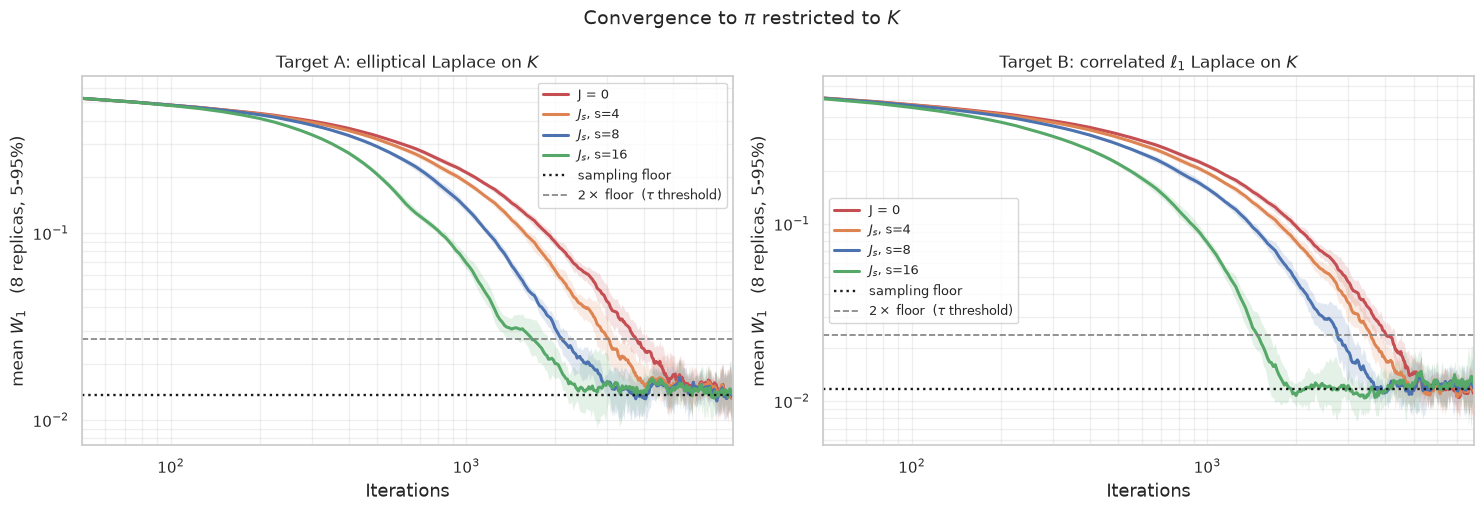

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for ax, kind in zip(axes, TARGETS):
    for lab in MAIN:
        r = RES[kind][lab]
        ax.plot(r["it"], r["W"].mean(axis=0), linewidth=2.2, color=COL[lab], label=lab)
        ax.fill_between(r["it"], np.percentile(r["W"], 5, axis=0),
                        np.percentile(r["W"], 95, axis=0), color=COL[lab], alpha=0.16, linewidth=0)
    ax.axhline(floors[kind], color="k", linestyle=":", linewidth=1.7, label="sampling floor")
    ax.axhline(2 * floors[kind], color="0.5", linestyle="--", linewidth=1.2,
               label=r"$2\times$ floor  ($\tau$ threshold)")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(50, MAXIT)
    ax.set_xlabel("Iterations", fontsize=13)
    ax.set_ylabel(r"mean $W_1$   ({} replicas, 5-95%)".format(REPLICAS), fontsize=12)
    ax.set_title(TARGETS[kind], fontsize=12)
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=9)
fig.suptitle(r"Convergence to $\pi$ restricted to $K$", fontsize=14)
plt.tight_layout()
plt.savefig("figures/ball_w1.pdf", dpi=300, bbox_inches="tight")
plt.show()

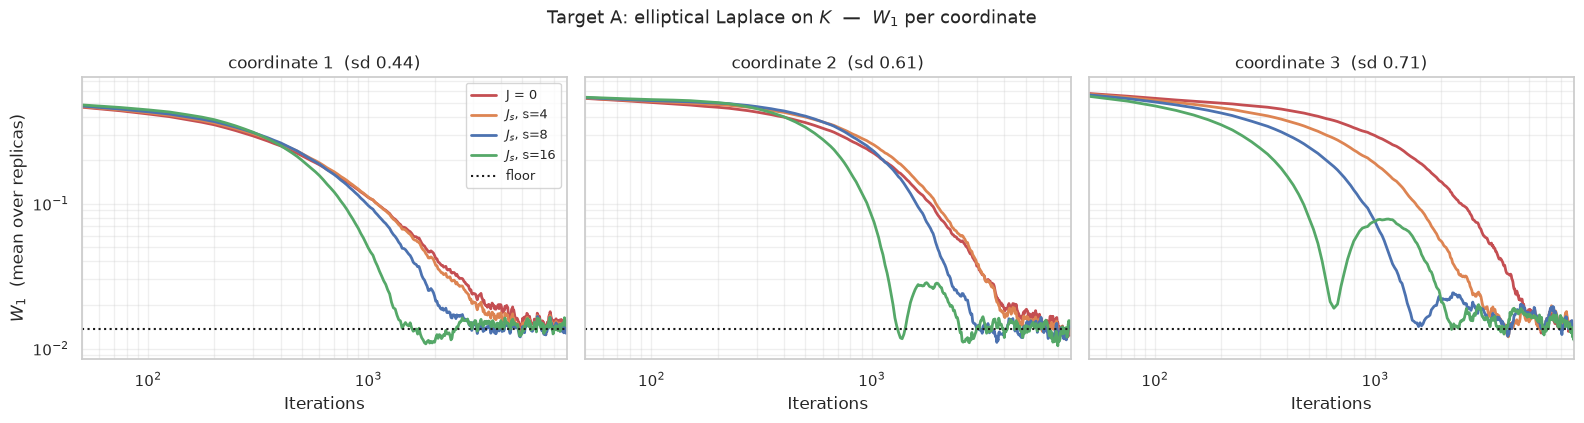

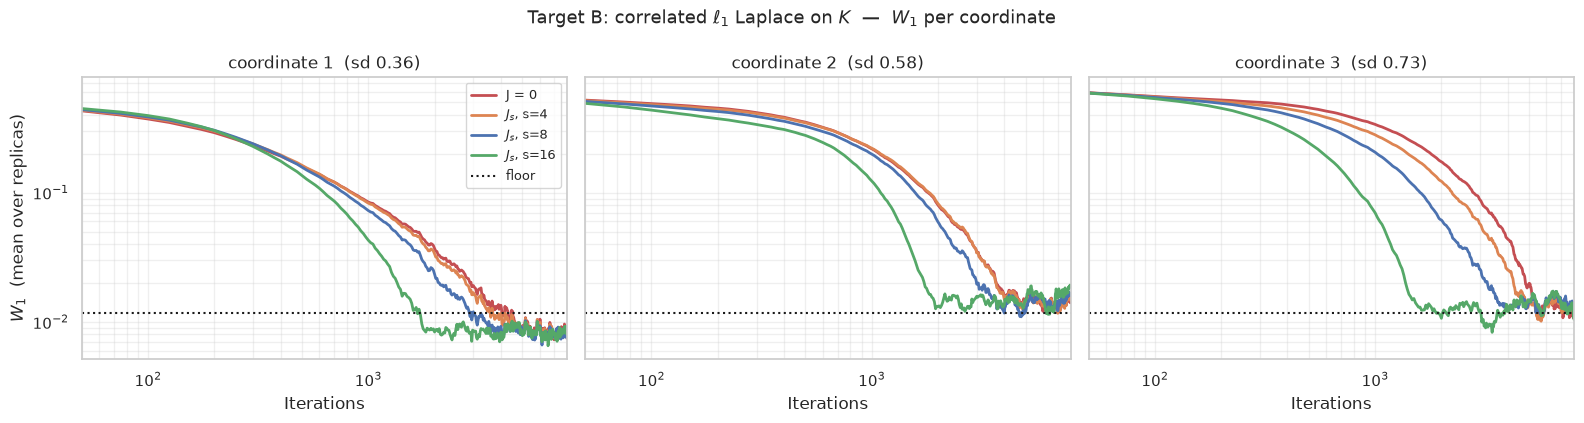

In [8]:
# per-coordinate W1: the three coordinates have very different length scales, so the
# mean above hides which direction the skew is actually helping
for kind in TARGETS:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), sharey=True)
    for i, ax in enumerate(axes):
        for lab in MAIN:
            r = RES[kind][lab]
            ax.plot(r["it"], r["Wc"][:, i], linewidth=2, color=COL[lab], label=lab)
        ax.axhline(floors[kind], color="k", linestyle=":", linewidth=1.5, label="floor")
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlim(50, MAXIT)
        ax.set_xlabel("Iterations", fontsize=12)
        ax.set_title("coordinate {}  (sd {:.2f})".format(i + 1, refs[kind][:, i].std()), fontsize=12)
        ax.grid(alpha=0.3, which="both")
    axes[0].set_ylabel(r"$W_1$  (mean over replicas)", fontsize=12)
    axes[0].legend(fontsize=9)
    fig.suptitle(TARGETS[kind] + r"  —  $W_1$ per coordinate", fontsize=13)
    plt.tight_layout()
    plt.savefig("figures/ball_w1_percoord_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

## Experiment 3 — the targets, inside $K$

The requested picture of the target in the constraint set. Top row: the 2-d marginal in dims 1 and 2 with
$\partial K$ drawn, reference first. Bottom row: the radial law of $\lVert x\rVert$, which is where the
constraint actually bites — projection deposits an atom at $\lVert x\rVert=R$ that the continuous target
does not have.

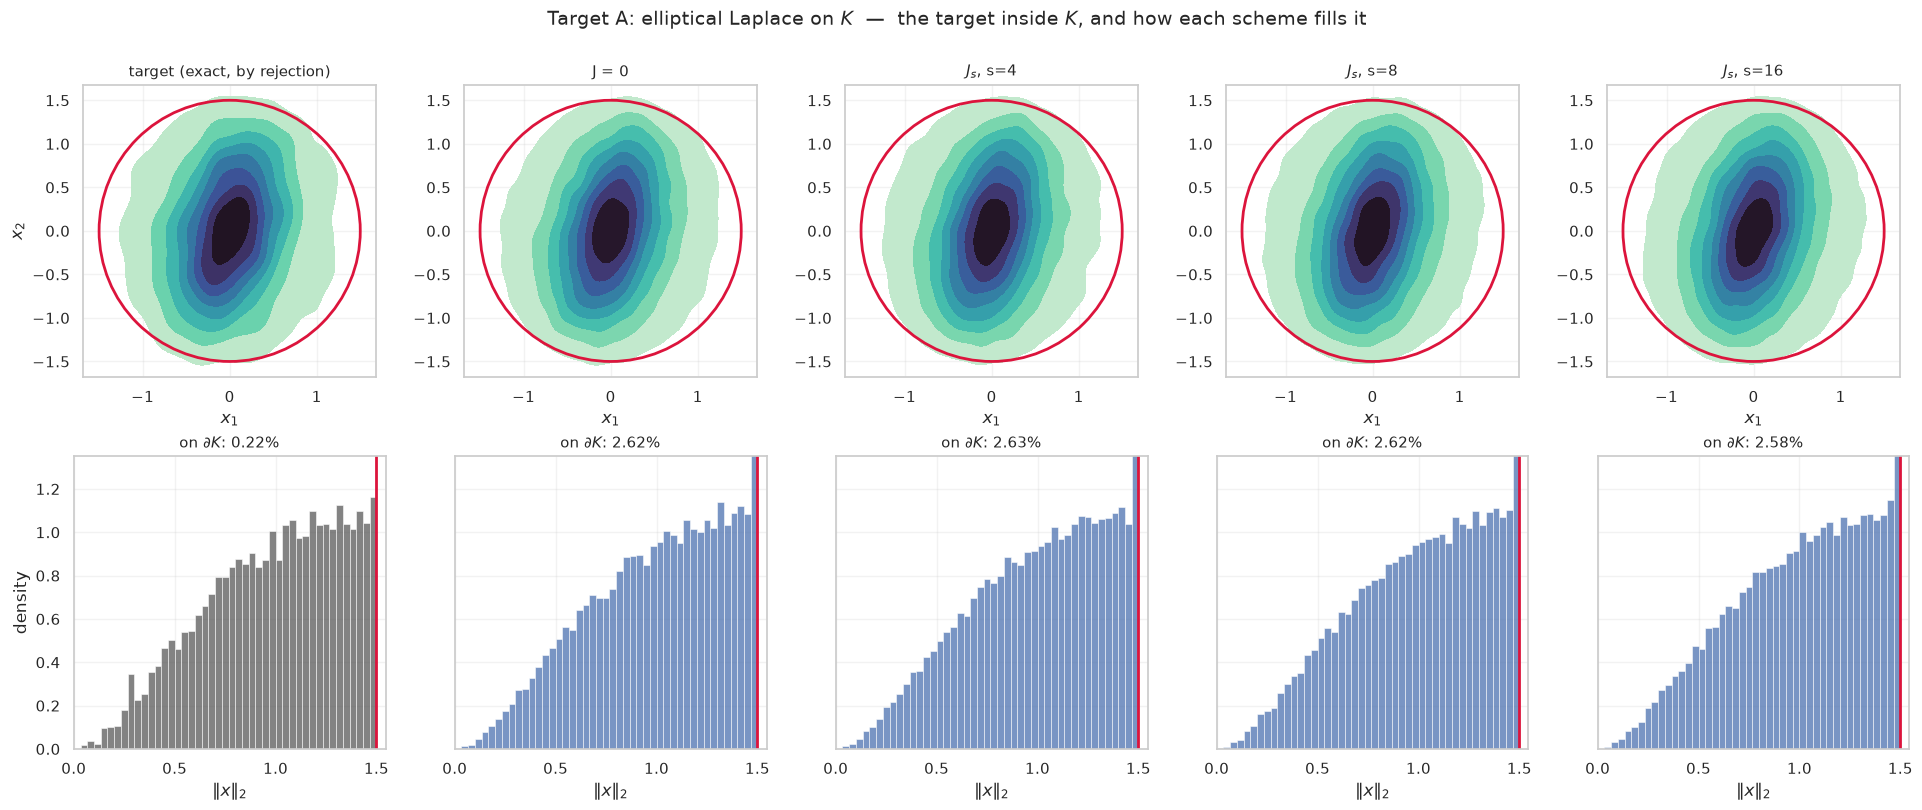

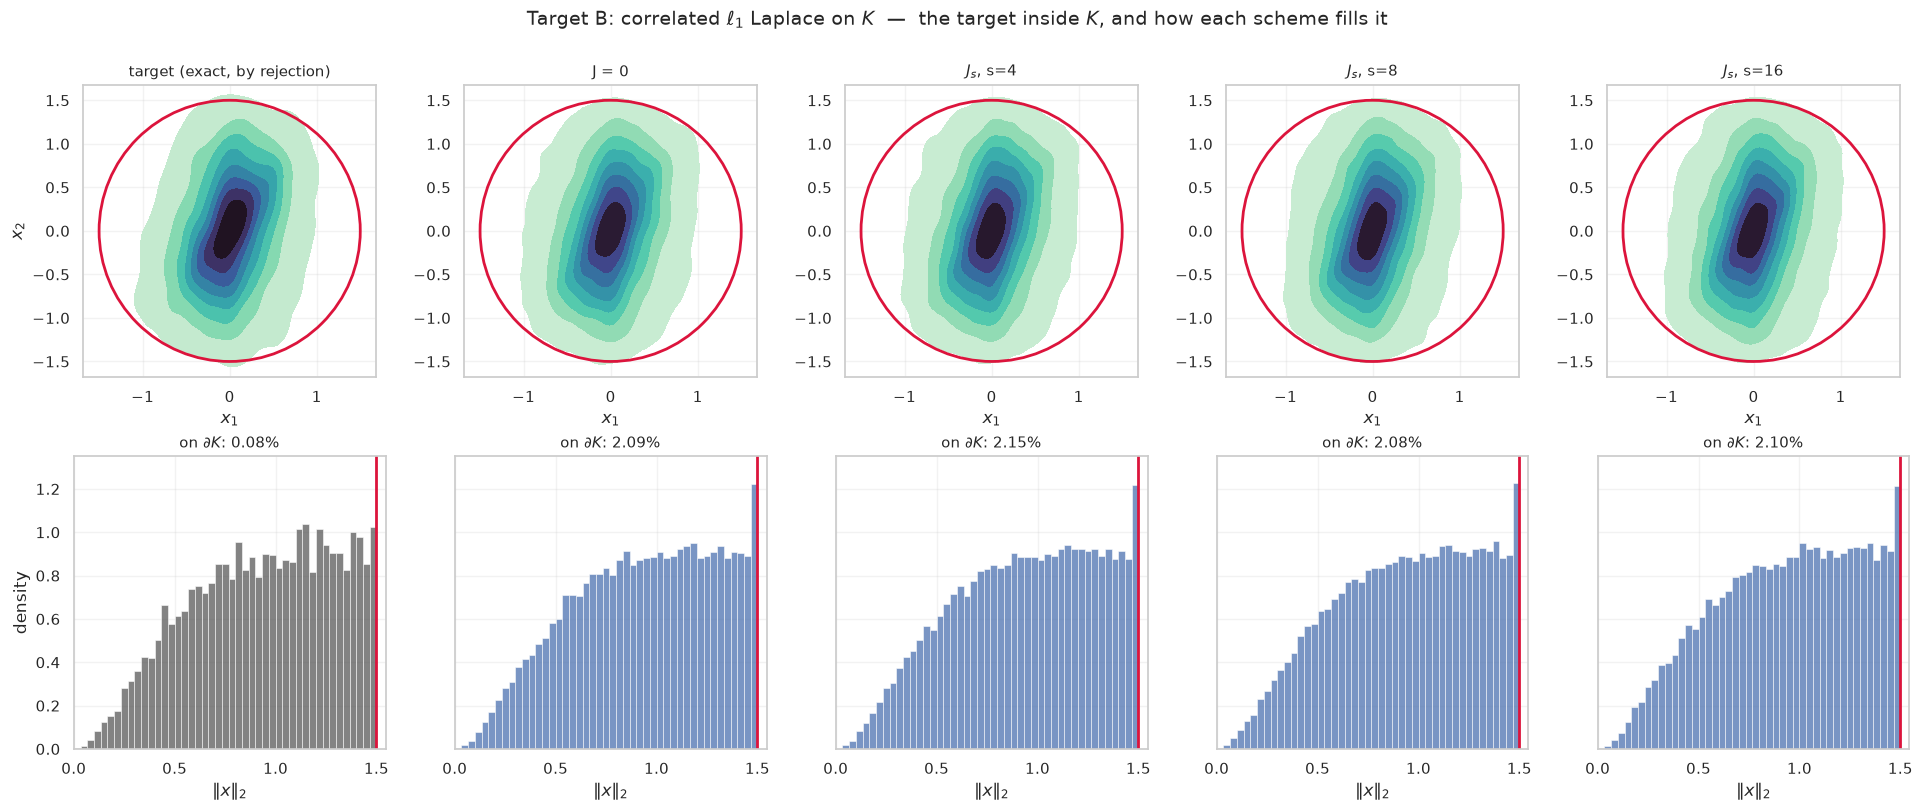

In [9]:
for kind in TARGETS:
    panels = [("target (exact, by rejection)", refs[kind])] + [
        (lab, RES[kind][lab]["X"].reshape(-1, d)) for lab in MAIN]
    fig, axes = plt.subplots(2, len(panels), figsize=(3.9 * len(panels), 8.0))
    for j, (name, X) in enumerate(panels):
        ax = axes[0, j]
        sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=9, ax=ax, thresh=0.02, cmap="mako_r")
        ax.add_patch(Circle((0, 0), R, edgecolor="crimson", facecolor="none", linewidth=2.0))
        ax.set_xlim(-1.12 * R, 1.12 * R); ax.set_ylim(-1.12 * R, 1.12 * R)
        ax.set_title(name, fontsize=11)
        ax.set_xlabel("$x_1$", fontsize=12)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.25)
        if j == 0:
            ax.set_ylabel("$x_2$", fontsize=12)
        ax = axes[1, j]
        r = np.linalg.norm(X, axis=1)
        sns.histplot(x=r, bins=np.linspace(0, R, 46), stat="density", ax=ax,
                     color="#4C72B0" if j else "0.35", edgecolor=None)
        ax.axvline(R, color="crimson", linewidth=2.0)
        ax.set_xlim(0, 1.03 * R)
        ax.set_ylim(0, 1.35)                    # shared, so bar heights are comparable
        ax.set_xlabel(r"$\|x\|_2$", fontsize=12)
        ax.set_title("on $\\partial K$: {:.2%}".format(on_boundary(X)), fontsize=11)
        ax.grid(alpha=0.25)
        ax.set_ylabel("density" if j == 0 else "", fontsize=12)
        if j:
            ax.set_yticklabels([])
    fig.suptitle(TARGETS[kind] + r"  —  the target inside $K$, and how each scheme fills it",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig("figures/ball_inK_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

## Experiment 4 — head to head

In [10]:
for kind in TARGETS:
    base = RES[kind]["J = 0"]["taus"]
    rows = []
    for lab in MAIN:
        r = RES[kind][lab]
        ks = np.mean([max(ks_2samp(refs[kind][:, i], r["X"][j, :, i]).statistic for i in range(d))
                      for j in range(REPLICAS)])
        rows.append({"scheme": lab.replace("$", ""),
                     "tau": fmt_tau(boot(r["taus"])),
                     "speed-up": "--" if r["s"] == 0 else fmt_speed(boot_speedup(base, r["taus"])),
                     "stationary W1": "{:.4f} [{:.4f}, {:.4f}]".format(*boot(r["stat"])),
                     "max KS": round(float(ks), 4),
                     "mass on dK": "{:.2%}".format(r["bd"])})
    rows.append({"scheme": "target (truth)", "tau": "--", "speed-up": "--",
                 "stationary W1": "{:.4f}  (floor)".format(floors[kind]), "max KS": 0.0,
                 "mass on dK": "{:.2%}".format(on_boundary(refs[kind]))})
    print("\n### {}".format(TARGETS[kind]))
    display(pd.DataFrame(rows).set_index("scheme"))


### Target A: elliptical Laplace on $K$


,tau,speed-up,stationary W1,max KS,mass on dK
scheme,,,,,
J = 0,"3831 [3634, 4075]",--,"0.0137 [0.0122, 0.0155]",0.0204,2.62%
"J_s, s=4","3078 [2950, 3222]","1.24x [1.16, 1.34]","0.0135 [0.0119, 0.0153]",0.0188,2.63%
"J_s, s=8","2191 [2109, 2275]","1.75x [1.64, 1.88]","0.0136 [0.0119, 0.0155]",0.0182,2.62%
"J_s, s=16","1809 [1600, 2106]","2.12x [1.79, 2.44]","0.0141 [0.0126, 0.0159]",0.0196,2.58%
target (truth),--,--,0.0136 (floor),0.0000,0.22%



### Target B: correlated $\ell_1$ Laplace on $K$


,tau,speed-up,stationary W1,max KS,mass on dK
scheme,,,,,
J = 0,"4200 [4069, 4341]",--,"0.0116 [0.0104, 0.0128]",0.0188,2.09%
"J_s, s=4","3616 [3516, 3722]","1.16x [1.11, 1.21]","0.0119 [0.0108, 0.0130]",0.0185,2.15%
"J_s, s=8","2806 [2662, 2956]","1.50x [1.41, 1.59]","0.0125 [0.0111, 0.0140]",0.0208,2.08%
"J_s, s=16","1494 [1447, 1550]","2.81x [2.68, 2.94]","0.0130 [0.0110, 0.0152]",0.0211,2.10%
target (truth),--,--,0.0118 (floor),0.0000,0.08%


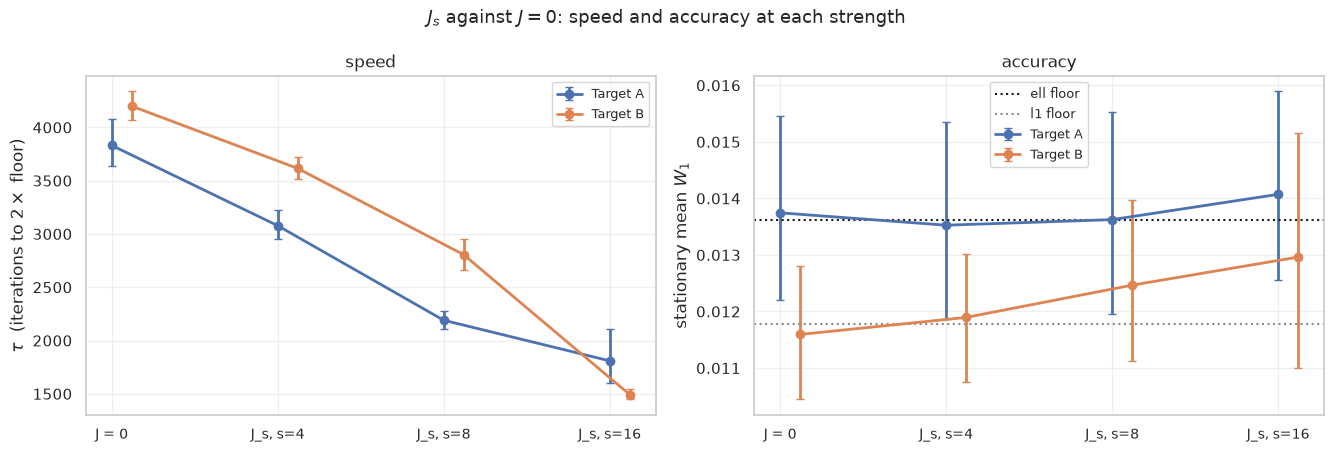

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
for col, kind in enumerate(TARGETS):
    base = RES[kind]["J = 0"]["taus"]
    ss = [0.0] + S_LIST
    tm = [boot(RES[kind][l]["taus"]) for l in MAIN]
    st = [boot(RES[kind][l]["stat"]) for l in MAIN]
    xs_ = np.arange(len(MAIN))
    axes[0].errorbar(xs_ + col * 0.12, [v[0] for v in tm],
                     yerr=[[v[0] - v[1] for v in tm], [v[2] - v[0] for v in tm]],
                     fmt="o-", capsize=3, linewidth=2, label=TARGETS[kind].split(":")[0])
    axes[1].errorbar(xs_ + col * 0.12, [v[0] for v in st],
                     yerr=[[v[0] - v[1] for v in st], [v[2] - v[0] for v in st]],
                     fmt="o-", capsize=3, linewidth=2, label=TARGETS[kind].split(":")[0])
    axes[1].axhline(floors[kind], linestyle=":", linewidth=1.5,
                    color=["k", "0.55"][col], label="{} floor".format(kind))
for ax, ylab, title in [(axes[0], r"$\tau$  (iterations to $2\times$ floor)", "speed"),
                        (axes[1], r"stationary mean $W_1$", "accuracy")]:
    ax.set_xticks(np.arange(len(MAIN)))
    ax.set_xticklabels([l.replace("$", "") for l in MAIN], fontsize=10)
    ax.set_ylabel(ylab, fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
fig.suptitle(r"$J_s$ against $J=0$: speed and accuracy at each strength", fontsize=13)
plt.tight_layout()
plt.savefig("figures/ball_summary.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 5 — spending the speed-up on the boundary atom

At fixed $\eta$ the atom is flat across $s$, and it has to be: it is a **discretisation** artefact of the
projection, driven by the *normal* component of a step near the wall, and $J_s$ is tangential — it adds no
normal drift at all. Nothing about a tangential field can remove it while $\eta$ is held fixed.

But it scales like $\sqrt\eta$, and the speed-up is real, so it can be spent. Refining $\eta$ by a factor
$c$ multiplies the iterations needed by about $c$ and the atom by about $1/\sqrt c$. As long as
$c$ is below the speed-up, $J_s$ at the finer stepsize converges in **fewer** iterations than $J=0$ at the
coarse one *and* leaves **less** mass on the wall.

In [12]:
REFINE = [1, 2, 4]                      # eta -> eta / c
RES_R = {}
for kind in TARGETS:
    RES_R[kind] = {}
    for c in REFINE[1:]:
        lab = "$J_s$, s=16, $\\eta$/{}".format(c)
        t0 = time.time()
        it, W, Wc, X = run_replicas(kind, 16.0, A_SLOW, refs[kind],
                                    n_steps=MAXIT * c, eta=eta / c)
        RES_R[kind][lab] = {"it": it, "W": W, "Wc": Wc, "X": X, "s": 16.0, "c": c,
                            "taus": np.array([tau_one(it, w, 2 * floors[kind]) for w in W]),
                            "stat": W[:, -20:].mean(axis=1),
                            "bd": on_boundary(X.reshape(-1, d))}
        print("   {:<24} {:5.0f}s".format(kind + " eta/" + str(c), time.time() - t0), flush=True)

   ell eta/2                  128s


   ell eta/4                  257s


   l1 eta/2                   127s


   l1 eta/4                   246s


In [13]:
for kind in TARGETS:
    base = RES[kind]["J = 0"]["taus"]
    rows = []
    entries = [("$J = 0$", RES[kind]["J = 0"], 1),
               ("$J_s$, s=16", RES[kind]["$J_s$, s=16"], 1)]
    entries += [(k, v, v["c"]) for k, v in RES_R[kind].items()]
    for lab, r, c in entries:
        rows.append({"scheme": lab.replace("$", "").replace("\\eta", "eta"),
                     "eta": "{:.1e}".format(eta / c),
                     "tau (iterations)": fmt_tau(boot(r["taus"])),
                     "vs J=0 iterations": "--" if lab == "$J = 0$" else
                         "{:.2f}x".format(np.nanmean(base) / np.nanmean(r["taus"])),
                     "stationary W1": "{:.4f} [{:.4f}, {:.4f}]".format(*boot(r["stat"])),
                     "mass on dK": "{:.2%}".format(r["bd"]),
                     "atom / sqrt(eta)": round(r["bd"] / np.sqrt(eta / c), 3)})
    rows.append({"scheme": "target (truth)", "eta": "--", "tau (iterations)": "--",
                 "vs J=0 iterations": "--",
                 "stationary W1": "{:.4f}  (floor)".format(floors[kind]),
                 "mass on dK": "{:.2%}".format(on_boundary(refs[kind])), "atom / sqrt(eta)": "--"})
    print("\\n### {}".format(TARGETS[kind]))
    display(pd.DataFrame(rows).set_index("scheme"))

\n### Target A: elliptical Laplace on $K$


,eta,tau (iterations),vs J=0 iterations,stationary W1,mass on dK,atom / sqrt(eta)
scheme,,,,,,
J = 0,5.0e-04,"3831 [3634, 4075]",--,"0.0137 [0.0122, 0.0155]",2.62%,1.171
"J_s, s=16",5.0e-04,"1809 [1600, 2106]",2.12x,"0.0141 [0.0126, 0.0159]",2.58%,1.156
"J_s, s=16, eta/2",2.5e-04,"3081 [2928, 3244]",1.24x,"0.0128 [0.0118, 0.0137]",1.82%,1.151
"J_s, s=16, eta/4",1.3e-04,"7144 [6481, 7775]",0.54x,"0.0134 [0.0123, 0.0147]",1.45%,1.295
target (truth),--,--,--,0.0136 (floor),0.22%,--


\n### Target B: correlated $\ell_1$ Laplace on $K$


,eta,tau (iterations),vs J=0 iterations,stationary W1,mass on dK,atom / sqrt(eta)
scheme,,,,,,
J = 0,5.0e-04,"4200 [4069, 4341]",--,"0.0116 [0.0104, 0.0128]",2.09%,0.934
"J_s, s=16",5.0e-04,"1494 [1447, 1550]",2.81x,"0.0130 [0.0110, 0.0152]",2.10%,0.941
"J_s, s=16, eta/2",2.5e-04,"3047 [2969, 3128]",1.38x,"0.0118 [0.0108, 0.0128]",1.44%,0.908
"J_s, s=16, eta/4",1.3e-04,"5947 [5819, 6081]",0.71x,"0.0123 [0.0112, 0.0139]",1.06%,0.953
target (truth),--,--,--,0.0118 (floor),0.08%,--


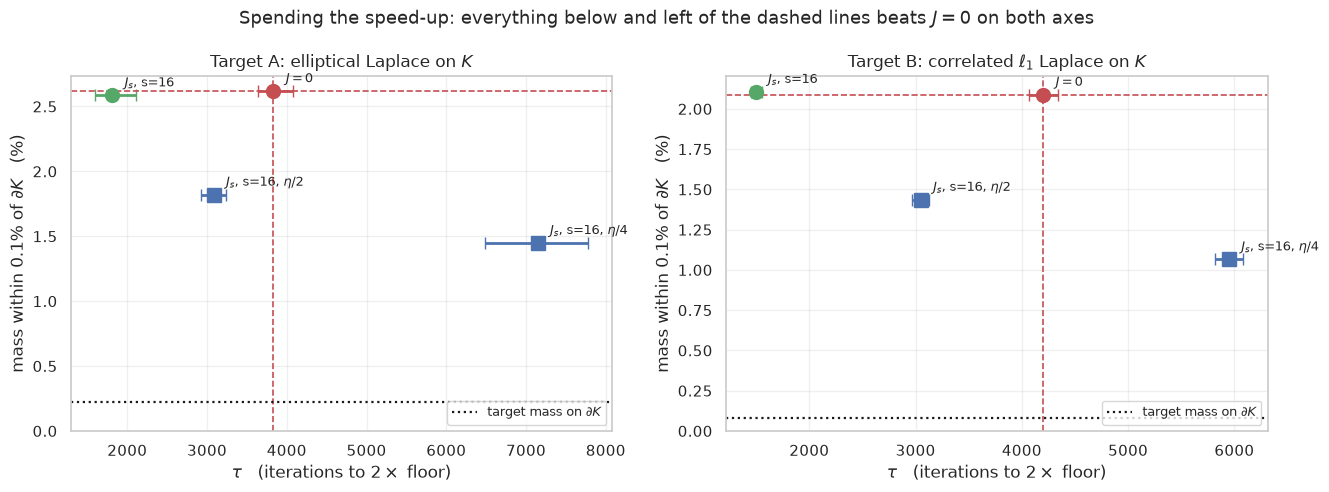

In [14]:
# the dominance picture: down and to the left is better on both axes at once
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
for ax, kind in zip(axes, TARGETS):
    pts = [("$J = 0$", RES[kind]["J = 0"], "#C44E52", "o"),
           ("$J_s$, s=16", RES[kind]["$J_s$, s=16"], "#55A868", "o")]
    pts += [(k, v, "#4C72B0", "s") for k, v in RES_R[kind].items()]
    for lab, r, c, mk in pts:
        t = boot(r["taus"])
        ax.errorbar(t[0], r["bd"] * 100, xerr=[[t[0] - t[1]], [t[2] - t[0]]],
                    fmt=mk, color=c, markersize=10, capsize=4, linewidth=2)
        ax.annotate(lab, (t[0], r["bd"] * 100), textcoords="offset points",
                    xytext=(9, 6), fontsize=9)
    j0 = boot(RES[kind]["J = 0"]["taus"])
    ax.axvline(j0[0], color="#C44E52", linestyle="--", linewidth=1.2)
    ax.axhline(RES[kind]["J = 0"]["bd"] * 100, color="#C44E52", linestyle="--", linewidth=1.2)
    ax.axhline(on_boundary(refs[kind]) * 100, color="k", linestyle=":", linewidth=1.6,
               label="target mass on $\\partial K$")
    ax.set_xlabel(r"$\tau$   (iterations to $2\times$ floor)", fontsize=12)
    ax.set_ylabel(r"mass within 0.1% of $\partial K$   (%)", fontsize=12)
    ax.set_title(TARGETS[kind], fontsize=12)
    ax.set_ylim(0, None)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc="lower right")
fig.suptitle("Spending the speed-up: everything below and left of the dashed lines beats "
             r"$J=0$ on both axes", fontsize=13)
plt.tight_layout()
plt.savefig("figures/ball_atom_tradeoff.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Both targets inside $K$, side by side

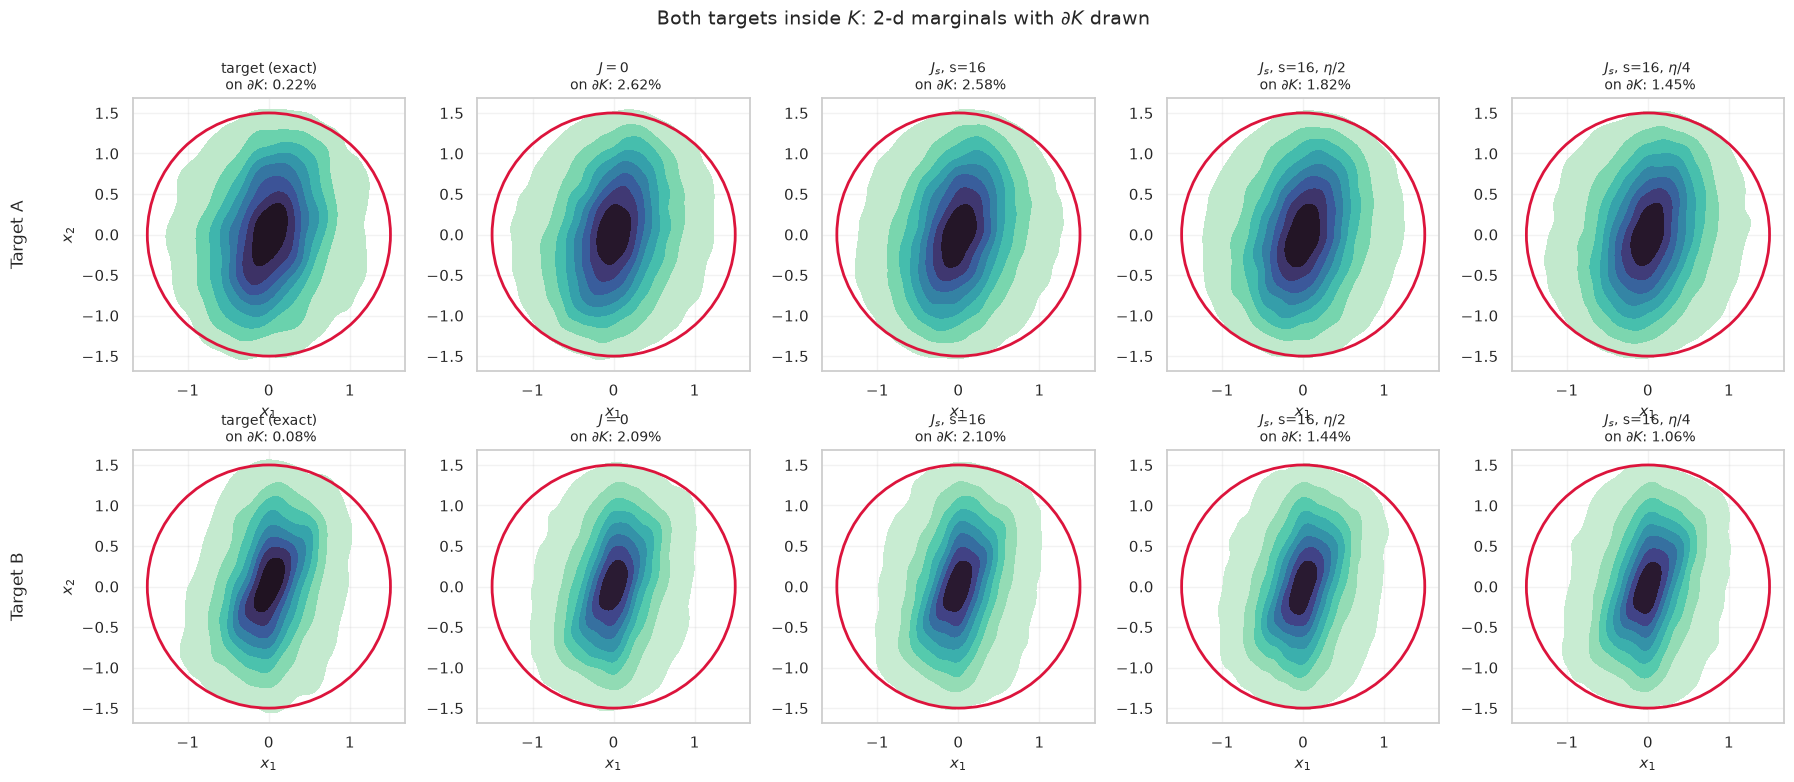

In [15]:
SHOW = [("target (exact)", None), ("$J = 0$", "J = 0"), ("$J_s$, s=16", "$J_s$, s=16"),
        ("$J_s$, s=16, $\\eta$/2", "$J_s$, s=16, $\\eta$/2"),
        ("$J_s$, s=16, $\\eta$/4", "$J_s$, s=16, $\\eta$/4")]
fig, axes = plt.subplots(2, len(SHOW), figsize=(3.6 * len(SHOW), 7.6))
for row, kind in enumerate(TARGETS):
    for col, (name, key) in enumerate(SHOW):
        X = refs[kind] if key is None else (
            RES[kind][key]["X"] if key in RES[kind] else RES_R[kind][key]["X"]).reshape(-1, d)
        ax = axes[row, col]
        sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=9, ax=ax, thresh=0.02, cmap="mako_r")
        ax.add_patch(Circle((0, 0), R, edgecolor="crimson", facecolor="none", linewidth=2.0))
        ax.set_xlim(-1.12 * R, 1.12 * R); ax.set_ylim(-1.12 * R, 1.12 * R)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title("{}\n on $\\partial K$: {:.2%}".format(name, on_boundary(X)), fontsize=10)
        ax.set_xlabel("$x_1$", fontsize=11)
        ax.set_ylabel("$x_2$" if col == 0 else "", fontsize=11)
        ax.grid(alpha=0.25)
    axes[row, 0].text(-0.42, 0.5, TARGETS[kind].split(":")[0], transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="center", fontsize=12)
fig.suptitle(r"Both targets inside $K$: 2-d marginals with $\partial K$ drawn", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures/ball_inK_both.pdf", dpi=300, bbox_inches="tight")
plt.show()

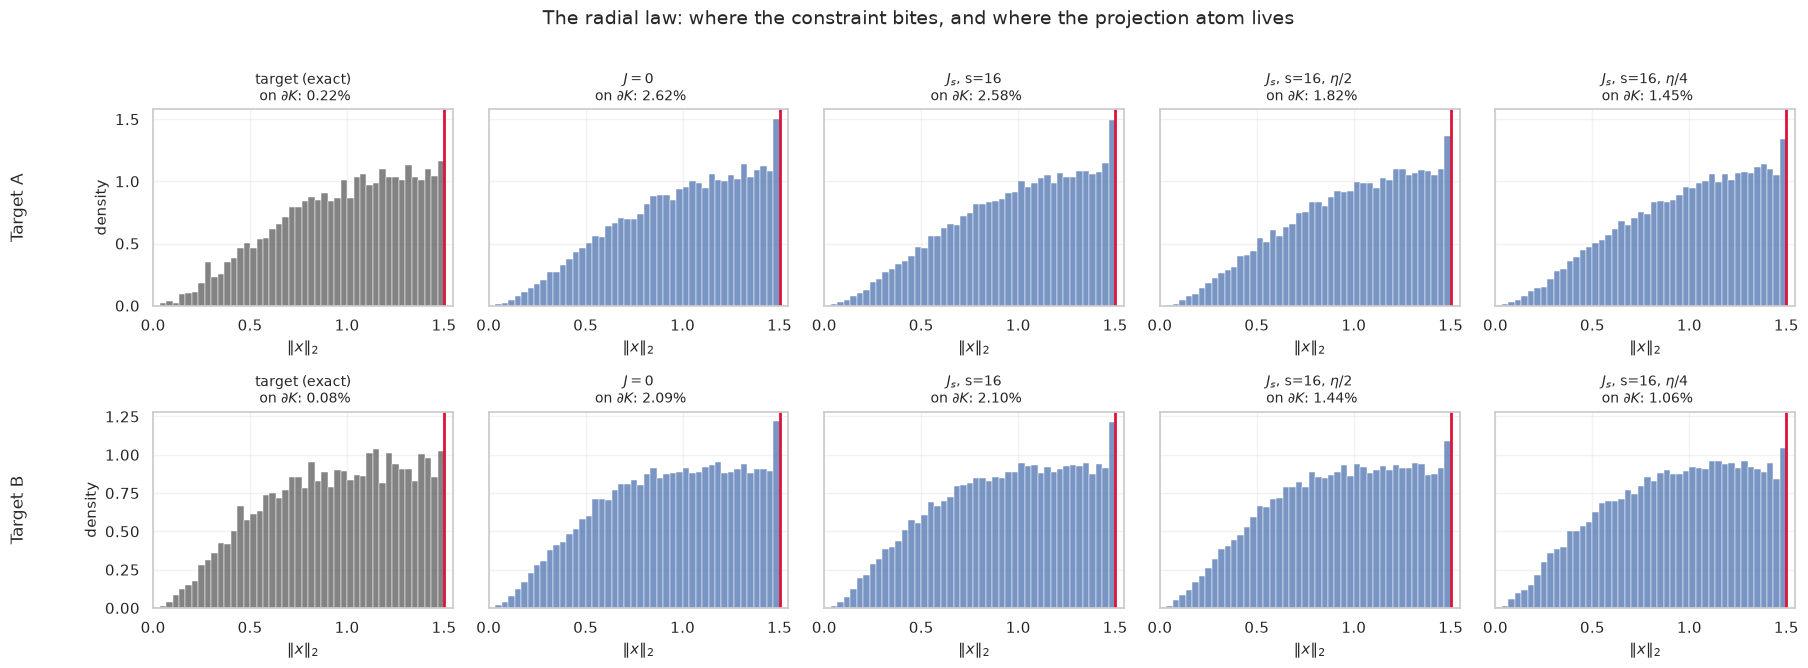

In [16]:
# the radial law, both targets, with the atom at the wall
fig, axes = plt.subplots(2, len(SHOW), figsize=(3.6 * len(SHOW), 6.6), sharey="row")
for row, kind in enumerate(TARGETS):
    for col, (name, key) in enumerate(SHOW):
        X = refs[kind] if key is None else (
            RES[kind][key]["X"] if key in RES[kind] else RES_R[kind][key]["X"]).reshape(-1, d)
        ax = axes[row, col]
        r = np.linalg.norm(X, axis=1)
        sns.histplot(x=r, bins=np.linspace(0, R, 46), stat="density", ax=ax,
                     color="0.35" if key is None else "#4C72B0", edgecolor=None)
        ax.axvline(R, color="crimson", linewidth=2.0)
        ax.set_xlim(0, 1.03 * R)
        ax.set_title("{}\n on $\\partial K$: {:.2%}".format(name, on_boundary(X)), fontsize=10)
        ax.set_xlabel(r"$\|x\|_2$", fontsize=11)
        ax.set_ylabel("density" if col == 0 else "", fontsize=11)
        ax.grid(alpha=0.25)
    axes[row, 0].text(-0.45, 0.5, TARGETS[kind].split(":")[0], transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="center", fontsize=12)
fig.suptitle(r"The radial law: where the constraint bites, and where the projection atom lives",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures/ball_radial_both.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Summary

$J=0$ against the admissible state-dependent skew $J_s$ at $s=4,8,16$, on both targets. The constant
$J_a$ does not appear: on a constrained problem it is not a candidate, since it fails $J\nu=0$ on
$\partial K$ by construction.

### The field is admissible at every strength

| $s$ | max $\lVert J+J^{\!\top}\rVert$ | $\lvert$div autograd − closed$\rvert$ | mean $\lVert J\nu\rVert$ on $\partial K$ | mean $\lVert\nabla\!\cdot J\rVert$ | mean $\lVert J\rVert_2$ |
|---|---|---|---|---|---|
| 4 | 2.2e-16 | 4.4e-16 | 3.5e-16 | 2.081 | 2.16 |
| 8 | 4.4e-16 | 8.9e-16 | 7.0e-16 | 4.162 | 4.31 |
| 16 | 8.9e-16 | 1.8e-15 | 1.4e-15 | 8.324 | 8.62 |

Tangency is structural — $J_s(x)x=0$ identically — so it holds to machine precision however hard the field
is pushed, while $\lVert J\rVert$ grows linearly in $s$. The divergence is genuinely non-zero, grows with
$s$, and is carried in the drift.

### Speed, at fixed stepsize

| | $\tau$ | speed-up | stationary $W_1$ | mass on $\partial K$ |
|---|---|---|---|---|
| **A** $J=0$ | 3831 [3634, 4075] | — | 0.0137 [0.0122, 0.0155] | 2.62% |
| A $J_s$, $s=4$ | 3078 [2950, 3222] | 1.24× [1.16, 1.34] | 0.0135 [0.0119, 0.0153] | 2.63% |
| A $J_s$, $s=8$ | 2191 [2109, 2275] | 1.75× [1.64, 1.88] | 0.0136 [0.0119, 0.0155] | 2.62% |
| A $J_s$, $s=16$ | 1809 [1600, 2106] | **2.12× [1.79, 2.44]** | 0.0141 [0.0126, 0.0159] | 2.58% |
| **B** $J=0$ | 4200 [4069, 4341] | — | 0.0116 [0.0104, 0.0128] | 2.09% |
| B $J_s$, $s=4$ | 3616 [3516, 3722] | 1.16× [1.11, 1.21] | 0.0119 [0.0108, 0.0130] | 2.15% |
| B $J_s$, $s=8$ | 2806 [2662, 2956] | 1.50× [1.41, 1.59] | 0.0125 [0.0111, 0.0140] | 2.08% |
| B $J_s$, $s=16$ | 1494 [1447, 1550] | **2.81× [2.68, 2.94]** | 0.0130 [0.0110, 0.0152] | 2.10% |

At these strengths the acceleration is free: every stationary $W_1$ interval overlaps $J=0$'s and straddles
the floor, and max KS moves by under 0.003.

### Getting the boundary atom below $J=0$

At fixed $\eta$ the atom is flat across $s$ (2.58-2.63% on A, 2.08-2.15% on B) and it has to be. The atom
is a **discretisation** artefact of the projection, set by the *normal* component of a step near the wall,
and $J_s$ is tangential — it contributes no normal drift, so it can neither create nor remove it. Anyone
expecting a tangential field to shrink the atom at fixed $\eta$ is expecting the wrong thing.

What it can do is **pay for a finer stepsize**. The atom scales like $\sqrt\eta$; refining by $c$ costs
about $c$ in iterations and buys about $1/\sqrt c$ on the atom. While $c$ stays under the speed-up, $J_s$
wins on both axes at once:

| | $\eta$ | $\tau$ | vs $J=0$ | stationary $W_1$ | mass on $\partial K$ | atom$/\sqrt\eta$ |
|---|---|---|---|---|---|---|
| **A** $J=0$ | 5.0e-4 | 3831 [3634, 4075] | — | 0.0137 | 2.62% | 1.171 |
| A $J_s$, $s=16$ | 5.0e-4 | 1809 [1600, 2106] | 2.12× | 0.0141 | 2.58% | 1.156 |
| **A $J_s$, $s=16$, $\eta/2$** | 2.5e-4 | 3081 [2928, 3244] | **1.24×** | 0.0128 | **1.82%** | 1.151 |
| A $J_s$, $s=16$, $\eta/4$ | 1.3e-4 | 7144 [6481, 7775] | 0.54× | 0.0134 | 1.45% | 1.295 |
| **B** $J=0$ | 5.0e-4 | 4200 [4069, 4341] | — | 0.0116 | 2.09% | 0.934 |
| B $J_s$, $s=16$ | 5.0e-4 | 1494 [1447, 1550] | 2.81× | 0.0130 | 2.10% | 0.941 |
| **B $J_s$, $s=16$, $\eta/2$** | 2.5e-4 | 3047 [2969, 3128] | **1.38×** | 0.0118 | **1.44%** | 0.908 |
| B $J_s$, $s=16$, $\eta/4$ | 1.3e-4 | 5947 [5819, 6081] | 0.71× | 0.0123 | 1.06% | 0.953 |

**$J_s$ at $s=16$ with $\eta/2$ is the answer**: it reaches the floor in 1.24× and 1.38× fewer iterations
than $J=0$ *and* leaves 31% less mass on the wall (1.82% against 2.62%, 1.44% against 2.09%), with a
stationary $W_1$ that is no worse and on target A slightly better. On the trade-off figure it is the point
below and to the left of both dashed lines.

Push to $\eta/4$ and the atom falls further (1.45% and 1.06%) but the iteration count crosses back above
$J=0$ — $c=4$ exceeds the 2.12× speed-up on target A, and eats most of the 2.81× on B. The refinement is
budgeted by the speed-up, and $\eta/2$ is what the budget affords.

The $\sqrt\eta$ scaling is confirmed by the last column: atom$/\sqrt\eta$ is constant to within a few
percent across a 4× refinement (1.151-1.295 on A, 0.908-0.953 on B), so the atom really does vanish in the
limit rather than converging to something non-zero.

### Aiming is most of the effect

Same field, same $s=16$, only the rotation plane changes:

| target | rotation plane | $\tau$ | speed-up |
|---|---|---|---|
| A | slow (two largest-variance eigenvectors) | 1809 [1600, 2106] | **2.12× [1.79, 2.44]** |
| A | fast (two smallest) | 3681 [3484, 3897] | 1.04× [0.96, 1.13] |
| A | arbitrary | 2950 [2809, 3094] | 1.30× [1.21, 1.40] |
| B | slow | 1494 [1447, 1550] | **2.81× [2.68, 2.94]** |
| B | fast | 3684 [3528, 3866] | 1.14× [1.08, 1.20] |
| B | arbitrary | 3144 [2984, 3288] | 1.34× [1.26, 1.42] |

Aimed at the fast plane the field buys nothing — the interval covers 1 on target A. An arbitrary axis
recovers about a third of what is available. This is the argument for the $A$-parameterised field over the
cross product $s\,(x\times w)$: the latter is equally admissible, but rotates about $x$, so its plane is
set by position rather than by $\Sigma$ and cannot be pointed anywhere.

### Both targets inside $K$

The 2-d marginals sit inside $\partial K$ for every scheme and are visually indistinguishable from the
reference on both targets; the constraint does not bite in any coordinate pair. It bites **radially**, and
the radial panels show it: the continuous target puts 0.22% (A) and 0.08% (B) of its mass within 0.1% of
the wall, against 2.62% and 2.09% for the projected chain at the base stepsize — and 1.82% and 1.44% once
the speed-up is spent on refining $\eta$.